# Trade SHAP Diagnostics: Model-to-Trading Feedback
**Docker image**: `ml4t`

**Purpose**: Demonstrate the `TradeShapAnalyzer` workflow that converts post-hoc
trade failures into actionable model-improvement hypotheses by clustering SHAP
decompositions of the worst trades.

**Learning objectives**:
1. Build trade records and aligned SHAP explanations from a fitted model.
2. Run `TradeShapAnalyzer.explain_worst_trades()` end-to-end.
3. Read clustered error patterns and the hypotheses the library generates.
4. Connect SHAP-driven diagnosis to feature-engineering or regime decisions.

**Book reference**: §19.5 (Trade-Level SHAP as Diagnostic Tool).

**Prerequisites**: Familiarity with SHAP values (Lundberg & Lee 2017), gradient
boosting on cross-sectional features, and the ML4T trade-record contract
(`ml4t.diagnostic.integration.backtest_contract.TradeRecord`).

**Data**: Real SPY daily OHLCV (`load_etfs`) joined with a fixed local FRED
snapshot (`load_macro`: 10Y-2Y yield slope and VIX-derived volatility regime).
Predictors are lagged one trading session before forecasting the next-session
SPY return. The macro snapshot is finalized rather than point-in-time vintage
data, so this is a diagnostic teaching example, not an unbiased macro backtest.

## Setup

In [1]:
"""Connect trade outcomes to their decision-time SHAP explanations."""

import lightgbm as lgb
import numpy as np
import pandas as pd
import plotly.express as px
import polars as pl
import shap
from IPython.display import Markdown, display
from ml4t.diagnostic.config import TradeConfig
from ml4t.diagnostic.config.trade_analysis_config import ExtractionSettings
from ml4t.diagnostic.evaluation import TradeAnalysis, TradeShapAnalyzer
from ml4t.diagnostic.integration.backtest_contract import TradeRecord

from data import load_etfs, load_macro
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

In [2]:
START_DATE = "2006-01-01"
END_DATE = "2025-12-31"
N_ESTIMATORS = 100
MAX_BIN = 255
TRAIN_FRACTION = 0.70
WORST_N = 20
MIN_EXPECTED_RETURN_BPS = 5
STRESS_VIX_LEVEL = 25
MOMENTUM_WINDOW = 20
VOLATILITY_WINDOW = 20
VOLUME_WINDOW = 60
SEED = 42
LGB_DEVICE = "cpu"

In [3]:
FEATURE_COLS = ["momentum", "volatility", "volume_zscore", "regime", "yield_slope"]
LABEL_HORIZON = 1
MIN_EXPECTED_RETURN = MIN_EXPECTED_RETURN_BPS / 10_000

In [4]:
set_global_seeds(SEED)

What each setting decides:

- `TRAIN_FRACTION` splits the sample chronologically. Everything before the boundary fits the
  model; everything after is the population the diagnosis runs on, and the model has never seen
  any of it.
- `MIN_EXPECTED_RETURN_BPS` is the forecast a prediction must clear before the notebook opens a
  position. Without it, every session with a forecast a hair above zero becomes a trade, and the
  worst-trade analysis fills with positions nobody would have taken. It stands in for the costs
  `18_transaction_costs` measures; those are not charged here.
- `WORST_N` is how many losing trades the SHAP analysis dissects. Small enough that each cluster
  can be read individually, large enough that clusters exist.
- `STRESS_VIX_LEVEL` is the volatility index level above which a session is labelled stressed,
  which is the `regime` feature. It is a round number, not a fitted boundary.
- `MOMENTUM_WINDOW`, `VOLATILITY_WINDOW` and `VOLUME_WINDOW` are the lookbacks the three
  price-derived features are computed over.
- `N_ESTIMATORS` bounds model capacity, and `MAX_BIN` is how many buckets each feature is
  binned into before the split search runs; 255 is LightGBM's own default.
- `LGB_DEVICE` is the backend LightGBM is asked for. It is `cpu`, which every install has, and
  the fitted booster is checked against it after the fit.

## 1. Build a Real Single-Asset Feature Panel

We build a single-asset SPY feature panel from real OHLCV joined with real
macro features and train an LGBM regressor on the next-session return. Keeping
the panel single-asset (one row per timestamp) makes the `TradeShapAnalyzer`
alignment unambiguous: each trade has exactly one SHAP vector to attach. In
practice you would feed in a multi-asset panel with composite
`(timestamp, symbol)` keys, or pre-aggregate to one row per trade before
calling the analyzer. All predictors are shifted by one session. A signal for
close $t$ therefore uses information through close $t-1$, and its label is the
close-to-close return from $t$ to the next market session.

In [5]:
# Load a bounded, unique SPY panel and the two required macro fields.
spy = load_etfs(symbols=["SPY"], start_date=START_DATE, end_date=END_DATE).sort("timestamp")
macro = load_macro(series=["t10y2y", "vixcls"], start_date=START_DATE, end_date=END_DATE).sort(
    "timestamp"
)
macro = macro.rename({column: column.lower() for column in macro.columns})
macro = macro.select(
    "timestamp",
    yield_slope="t10y2y",
    regime=(pl.col("vixcls") > STRESS_VIX_LEVEL).cast(pl.Int8),
)
assert spy.n_unique(["symbol", "timestamp"]) == spy.height
assert macro["timestamp"].n_unique() == macro.height

The transformation retains actual entry and next-session exit prices for the
trade ledger, computes the forward label directly from those prices, and then
lags every predictor one session before dropping incomplete rows.

In [6]:
features_df = (
    spy.with_columns(
        _ret=pl.col("close").pct_change(),
        exit_timestamp=pl.col("timestamp").shift(-1),
        exit_price=pl.col("close").shift(-1),
    )
    .with_columns(
        momentum=(pl.col("close") / pl.col("close").shift(MOMENTUM_WINDOW) - 1),
        volatility=pl.col("_ret").rolling_std(VOLATILITY_WINDOW),
        volume_zscore=(
            (pl.col("volume") - pl.col("volume").rolling_mean(VOLUME_WINDOW))
            / pl.col("volume").rolling_std(VOLUME_WINDOW)
        ),
        fwd_return=(pl.col("exit_price") / pl.col("close") - 1),
    )
    .join_asof(macro, on="timestamp", strategy="backward")
    .with_columns(pl.col(FEATURE_COLS).shift(1))
    .select(
        pl.col("timestamp").cast(pl.Datetime("us")),
        pl.col("exit_timestamp").cast(pl.Datetime("us")),
        pl.col("close").alias("entry_price"),
        "exit_price",
        "fwd_return",
        *FEATURE_COLS,
    )
    .drop_nulls()
    .sort("timestamp")
)

In [7]:
np.testing.assert_allclose(
    features_df["fwd_return"],
    features_df["exit_price"] / features_df["entry_price"] - 1,
    rtol=0,
    atol=1e-15,
)
assert features_df["timestamp"].n_unique() == features_df.height
assert features_df["exit_timestamp"].n_unique() == features_df.height
assert features_df.select((pl.col("exit_timestamp") > pl.col("timestamp")).all()).item()

display(
    Markdown(
        f"The lagged feature panel contains **{features_df.height:,} sessions** from "
        f"{features_df['timestamp'].min().date()} through {features_df['timestamp'].max().date()}. "
        "Each row carries its exact next-market-session exit timestamp."
    )
)

The lagged feature panel contains **4,970 sessions** from 2006-03-30 through 2025-12-30. Each row carries its exact next-market-session exit timestamp.

## 2. Train ML Model

A chronological boundary separates model fitting from the diagnostic sample.
Because each label spans one session, the row immediately before the
test boundary is purged: its return ends on the first test decision date.

In [8]:
features_df = features_df.sort("timestamp")
split_idx = int(len(features_df) * TRAIN_FRACTION)
train_df = features_df[: split_idx - LABEL_HORIZON]
embargo_df = features_df[split_idx - LABEL_HORIZON : split_idx]
test_df = features_df[split_idx:]
assert embargo_df.height == LABEL_HORIZON
assert train_df["exit_timestamp"].max() < test_df["timestamp"].min()

X_train = train_df.select(FEATURE_COLS).to_numpy()
y_train = train_df["fwd_return"].to_numpy()
X_test = test_df.select(FEATURE_COLS).to_numpy()
y_test = test_df["fwd_return"].to_numpy()

LightGBM fits on one CPU thread with every seed fixed, which makes the boosted trees
bitwise reproducible: the same predictions, the same trades, and the same SHAP vectors on
every run. That is a property of the backend rather than of the seeds - a CUDA fit with
these same seeds would not give it, because its histogram reductions vary with how the
card schedules them. Asking for a backend this LightGBM was not built with raises at `fit()`
rather than quietly substituting another, so the assertion below is not catching a fallback:
it reads back the device the booster kept, and a requested value that never reached it would
otherwise leave no trace.

In [9]:
model = lgb.LGBMRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=3,
    learning_rate=0.1,
    max_bin=MAX_BIN,
    device_type=LGB_DEVICE,
    random_state=SEED,
    data_random_seed=SEED,
    feature_fraction_seed=SEED,
    bagging_seed=SEED,
    n_jobs=1,
    verbose=-1,
)
model.fit(X_train, y_train)
fitted_device = str(model.booster_.params.get("device_type", "")).lower()
assert fitted_device == LGB_DEVICE, (
    f"LightGBM device mismatch: required {LGB_DEVICE}, observed {fitted_device or 'unset'}"
)

predictions = model.booster_.predict(X_test)
display(
    Markdown(
        f"LightGBM fits **{len(X_train):,} training rows** on {fitted_device.upper()} "
        f"and diagnoses **{len(X_test):,} later rows**. The one-session purge ends training "
        f"labels before the test boundary at {test_df['timestamp'].min().date()}."
    )
)

LightGBM fits **3,478 training rows** on CPU and diagnoses **1,491 later rows**. The one-session purge ends training labels before the test boundary at 2020-01-27.

## 3. Construct Model-Directed Trade Records

A market-on-close order for session $t$ is determined from predictors through
$t-1$. A forecast must clear a fixed execution-and-noise buffer before opening
a 100-share long at close $t$; smaller positive forecasts are economically
negligible for this one-session example. The trade exits at the next observed
market close. Exact timestamps avoid calendar-day assumptions around weekends
and holidays.

In [10]:
entry_timestamps = test_df["timestamp"].to_list()
exit_timestamps = test_df["exit_timestamp"].to_list()
entry_prices = test_df["entry_price"].to_numpy()
exit_prices = test_df["exit_price"].to_numpy()
test_returns = y_test
SYMBOL = "SPY"
QUANTITY = 100

In [11]:
trade_dicts = []
for row_id, (entry_time, exit_time, entry_price, exit_price, pred, actual) in enumerate(
    zip(
        entry_timestamps,
        exit_timestamps,
        entry_prices,
        exit_prices,
        predictions,
        test_returns,
        strict=True,
    )
):
    if pred > MIN_EXPECTED_RETURN:
        pnl = (exit_price - entry_price) * QUANTITY
        trade_dicts.append(
            {
                "row_id": row_id,
                "entry_time": entry_time,
                "exit_time": exit_time,
                "symbol": SYMBOL,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "pnl": pnl,
                "return": actual,
                "predicted_return": pred,
            }
        )

In [12]:
trade_records = [
    TradeRecord(
        timestamp=trade["exit_time"],
        symbol=trade["symbol"],
        entry_price=float(trade["entry_price"]),
        exit_price=float(trade["exit_price"]),
        pnl=float(trade["pnl"]),
        duration=trade["exit_time"] - trade["entry_time"],
        direction="long",
        quantity=QUANTITY,
        entry_timestamp=trade["entry_time"],
        metadata={
            "row_id": trade["row_id"],
            "predicted_return": float(trade["predicted_return"]),
            "actual_return": float(trade["return"]),
        },
    )
    for trade in trade_dicts
]

In [13]:
trades_df = pl.DataFrame(trade_dicts)
winning_trades = int((trades_df["pnl"] > 0).sum())
losing_trades = int((trades_df["pnl"] < 0).sum())
flat_trades = trades_df.height - winning_trades - losing_trades
display(
    Markdown(
        f"Forecasts above the fixed **{MIN_EXPECTED_RETURN_BPS} bp buffer** produce "
        f"**{trades_df.height:,} long trades**: "
        f"**{winning_trades:,} profitable**, **{losing_trades:,} at a loss**, and "
        f"**{flat_trades:,} flat**."
    )
)

Forecasts above the fixed **5 bp buffer** produce **620 long trades**: **330 profitable**, **289 at a loss**, and **1 flat**.

## 4. Identify Worst Trades with TradeAnalysis

TradeAnalysis extracts the worst-performing trades for diagnosis.

In [14]:
analyzer = TradeAnalysis(trade_records)
worst_trades = analyzer.worst_trades(n=WORST_N)
assert len(worst_trades) == min(WORST_N, len(trade_records))
assert all(
    left.pnl <= right.pnl for left, right in zip(worst_trades, worst_trades[1:], strict=False)
)

worst_summary = pl.DataFrame(
    [
        {
            "rank": i,
            "entry": trade.entry_timestamp,
            "symbol": trade.symbol,
            "pnl_usd": round(trade.pnl, 2),
            "return_pct": round(trade.return_pct * 100, 2),
        }
        for i, trade in enumerate(worst_trades[:5], 1)
    ]
)
worst_summary

rank,entry,symbol,pnl_usd,return_pct
i64,datetime[μs],str,f64,f64
1,2020-03-13 00:00:00,"""SPY""",-2693.17,-10.94
2,2025-04-09 00:00:00,"""SPY""",-2376.76,-4.38
3,2020-03-06 00:00:00,"""SPY""",-2122.91,-7.81
4,2022-09-12 00:00:00,"""SPY""",-1698.3,-4.35
5,2020-06-10 00:00:00,"""SPY""",-1690.49,-5.76


## 5. Compute Decision-Time SHAP Values

TreeSHAP explains the model output for every diagnostic row. The additivity
check verifies that base value plus feature contributions reconstructs each
prediction. For library alignment, each entry-feature vector is indexed by
its trade's exact exit timestamp because `TradeRecord.timestamp` is the exit
field in the integration contract.

In [15]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
expected_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])
np.testing.assert_allclose(
    expected_value + shap_values.sum(axis=1),
    predictions,
    rtol=1e-7,
    atol=1e-9,
)
assert shap_values.shape == X_test.shape

test_features = test_df.select(pl.col("exit_timestamp").alias("timestamp"), *FEATURE_COLS)
assert test_features["timestamp"].n_unique() == test_features.height
display(
    Markdown(
        f"TreeSHAP reconstructs all **{shap_values.shape[0]:,} predictions** across "
        f"**{shap_values.shape[1]} features** within numerical tolerance."
    )
)

TreeSHAP reconstructs all **1,491 predictions** across **5 features** within numerical tolerance.

## 6. Run TradeShapAnalyzer

Now we connect SHAP explanations to trade outcomes.

In [16]:
config = TradeConfig(
    extraction=ExtractionSettings(n_worst=WORST_N),
)

shap_analyzer = TradeShapAnalyzer(
    model=model,
    features_df=test_features,
    shap_values=shap_values,
    config=config,
)
assert shap_analyzer.feature_names == FEATURE_COLS

## 7. Full Pipeline: explain_worst_trades()

`explain_worst_trades()` runs the complete SHAP forensics pipeline in one call:
align timestamps, extract SHAP vectors, cluster patterns, characterize, and
generate hypotheses.

In [17]:
result = shap_analyzer.explain_worst_trades(worst_trades)
assert result.n_trades_analyzed == len(worst_trades)
assert result.n_trades_explained == len(worst_trades)
assert result.n_trades_failed == 0
display(
    Markdown(
        f"All **{result.n_trades_explained} worst trades** align to their decision-time SHAP "
        f"vectors. The library returns **{len(result.error_patterns)} algorithmic hierarchical "
        "clusters**, then annotates them with separation scores and corrected feature tests."
    )
)

All **20 worst trades** align to their decision-time SHAP vectors. The library returns **4 algorithmic hierarchical clusters**, then annotates them with separation scores and corrected feature tests.

## 8. Inspect Individual Explanations

Each explanation is joined back to its trade by the library's stable trade ID,
never by list position. This keeps PnL, prediction, entry, and SHAP values tied
to the same completed trade even if an analyzer returns a reordered subset.

In [18]:
worst_by_id = {f"{trade.symbol}_{trade.timestamp.isoformat()}": trade for trade in worst_trades}
assert set(worst_by_id) == {explanation.trade_id for explanation in result.explanations}
feature_rows_by_exit = {
    row["timestamp"]: np.array([row[feature] for feature in FEATURE_COLS])
    for row in test_features.iter_rows(named=True)
}

explanation_rows = []
for explanation in result.explanations:
    trade = worst_by_id[explanation.trade_id]
    metadata = trade.metadata or {}
    np.testing.assert_allclose(
        np.array([explanation.feature_values[feature] for feature in FEATURE_COLS]),
        feature_rows_by_exit[trade.timestamp],
        rtol=0,
        atol=0,
    )
    explanation_rows.append(
        {
            "trade_id": explanation.trade_id,
            "entry_time": trade.entry_timestamp,
            "exit_time": trade.timestamp,
            "pnl": trade.pnl,
            "predicted_return": metadata["predicted_return"],
            "actual_return": metadata["actual_return"],
            "top_feature": explanation.top_features[0][0],
            "top_shap": explanation.top_features[0][1],
        }
    )

explanation_df = pl.DataFrame(explanation_rows).sort("actual_return")
explanation_df.head(5)

trade_id,entry_time,exit_time,pnl,predicted_return,actual_return,top_feature,top_shap
str,datetime[μs],datetime[μs],f64,f64,f64,str,f64
"""SPY_2020-03-16T00:00:00""",2020-03-13 00:00:00,2020-03-16 00:00:00,-2693.167114,0.025742,-0.109424,"""momentum""",0.012007
"""SPY_2020-03-09T00:00:00""",2020-03-06 00:00:00,2020-03-09 00:00:00,-2122.912598,0.006894,-0.078094,"""momentum""",0.005185
"""SPY_2020-06-11T00:00:00""",2020-06-10 00:00:00,2020-06-11 00:00:00,-1690.490723,0.001157,-0.057649,"""volatility""",0.001481
"""SPY_2020-03-18T00:00:00""",2020-03-17 00:00:00,2020-03-18 00:00:00,-1169.747925,0.025051,-0.050633,"""momentum""",0.012651
"""SPY_2020-03-11T00:00:00""",2020-03-10 00:00:00,2020-03-11 00:00:00,-1284.901428,0.009225,-0.048748,"""momentum""",0.005729


## 9. Error Pattern Clustering

The library uses hierarchical clustering on normalized SHAP vectors to find
recurring error modes. Every cluster returned by the algorithm is characterized
and reported. Separation scores and false-discovery-rate-corrected feature tests
are diagnostics and annotations, not report-or-reject gates. When no tested
feature is significant, the characterizer falls back to its top-ranked features
when constructing the description.

In [19]:
if result.error_patterns:
    pattern_summary = pl.DataFrame(
        [
            {
                "cluster": pattern.cluster_id,
                "trades": pattern.n_trades,
                "separation": pattern.separation_score,
                "distinctiveness": pattern.distinctiveness,
                "hypothesis": pattern.hypothesis,
            }
            for pattern in result.error_patterns
        ]
    )
    display(pattern_summary)
else:
    display(
        Markdown(
            f"With **{len(result.explanations)} explained worst trades**, the pipeline returned no "
            "error pattern because clustering did not run or raised a clustering error. This does "
            "not represent rejection by a statistical or separation threshold."
        )
    )

cluster,trades,separation,distinctiveness,hypothesis
i64,i64,f64,f64,str
0,4,0.813401,1.692642,"""Trades are losing when volume_…"
1,9,0.813401,2.846257,"""Trades are losing when momentu…"
2,5,1.334558,0.78323,"""Trades are losing when momentu…"
3,2,1.181739,1.800698,null


## 10. Visualize Prediction Failures

Grouped bars compare forecasts with outcomes for the ten worst trades without
compressing the small positive forecasts against the much larger losses.

In [20]:
explanation_pd = explanation_df.to_pandas()
explanation_pd["predicted_pct"] = explanation_pd["predicted_return"] * 100
explanation_pd["actual_pct"] = explanation_pd["actual_return"] * 100
worst_miss = explanation_pd.loc[
    (explanation_pd["actual_pct"] - explanation_pd["predicted_pct"]).idxmin()
]
forecast_plot = explanation_pd.nsmallest(10, "actual_pct").copy()
forecast_plot["trade_label"] = [
    f"#{rank:02d} | {entry_time:%Y-%m-%d}"
    for rank, entry_time in enumerate(forecast_plot["entry_time"], 1)
]
forecast_long = forecast_plot.melt(
    id_vars=["trade_label", "pnl"],
    value_vars=["predicted_pct", "actual_pct"],
    var_name="series",
    value_name="return_pct",
)
forecast_long["series"] = forecast_long["series"].map(
    {"predicted_pct": "Predicted", "actual_pct": "Realized"}
)
entry_order = forecast_plot.sort_values("actual_pct", ascending=False)["trade_label"].tolist()

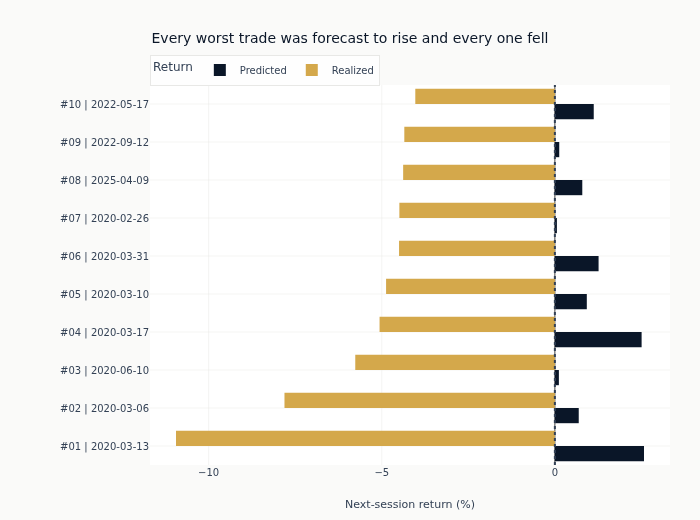

In [21]:
fig = px.bar(
    forecast_long,
    x="return_pct",
    y="trade_label",
    color="series",
    orientation="h",
    barmode="group",
    color_discrete_map={"Predicted": COLORS["blue"], "Realized": COLORS["amber"]},
    category_orders={"trade_label": entry_order},
    title="Every worst trade was forecast to rise and every one fell",
    labels={
        "return_pct": "Next-session return (%)",
        "trade_label": "",
        "series": "Return",
    },
)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_dash="dot")
fig.update_yaxes(automargin=True)
fig.update_layout(
    height=520,
    margin=dict(l=150, r=30, t=85, b=55),
    legend=dict(orientation="h", y=1.08),
)
show_plotly_with_alt(
    fig,
    "Paired horizontal bars per worst trade, forecast against realized next-session return. Every forecast bar points positive and every realized bar points negative, by varying amounts.",
)

## 11. Inspect Attribution Variability

Signed SHAP distributions show both direction and trade-to-trade dispersion.
Features are ordered by mean absolute contribution; values are expressed in
basis points of predicted next-session return.

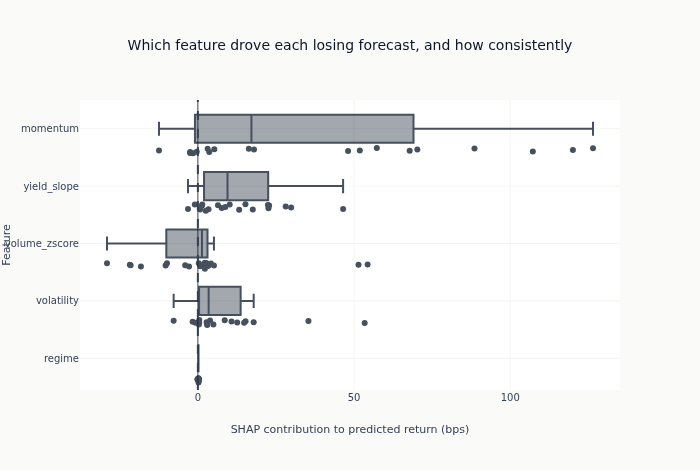

In [22]:
shap_vectors = shap_analyzer.extract_shap_vectors(result.explanations, normalization=None)
mean_abs_shap = np.abs(shap_vectors).mean(axis=0)
feature_order = [FEATURE_COLS[index] for index in np.argsort(mean_abs_shap)[::-1]]
dominant_feature = feature_order[0]

shap_long = pd.DataFrame(shap_vectors, columns=FEATURE_COLS).melt(
    var_name="feature", value_name="shap_value"
)
shap_long["shap_bps"] = shap_long["shap_value"] * 10_000
fig = px.box(
    shap_long,
    x="shap_bps",
    y="feature",
    category_orders={"feature": feature_order},
    points="all",
    title="Which feature drove each losing forecast, and how consistently",
    labels={"shap_bps": "SHAP contribution to predicted return (bps)", "feature": "Feature"},
)
fig.update_traces(marker_color=COLORS["blue"], line_color=COLORS["blue"], opacity=0.75)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_dash="dash")
fig.update_layout(height=470, showlegend=False)
show_plotly_with_alt(
    fig,
    "Box plots of SHAP contribution per feature across the worst trades, with individual points overlaid and a dashed line at zero. Several features straddle zero, so their contributions ran in both directions across the failures.",
)

The forecast gaps confirm that these selected trades are genuine model
failures, not merely low-PnL trades. The signed distributions then show which
features drove each forecast and how unstable those contributions are across
failures. SHAP remains predictive attribution, not a causal explanation.

## Key Takeaways

In [23]:
top_feature_counts = explanation_df.group_by("top_feature").len().sort("len", descending=True)
top_feature_name = top_feature_counts["top_feature"][0]
top_feature_trades = top_feature_counts["len"][0]
display(
    Markdown(
        f"Of the {len(result.explanations)} worst trades explained, **{top_feature_name}** was the "
        f"largest absolute contributor on **{top_feature_trades}**. The pipeline grouped them into "
        f"**{len(result.error_patterns)} clusters**. The trades came from "
        f"**{trades_df.height:,} model-directed longs**, of which "
        f"**{losing_trades:,}** lost money."
    )
)

Of the 20 worst trades explained, **momentum** was the largest absolute contributor on **12**. The pipeline grouped them into **4 clusters**. The trades came from **620 model-directed longs**, of which **289** lost money.

1. **Attach an explanation to the decision, not to the outcome's row.** A trade's SHAP vector has
   to be the one computed from the features the model actually saw when it opened the position.
   Joining on the exit date, or on row position across two frames that have dropped different
   rows, produces an explanation of a different decision and nothing complains.

2. **Screen out the trades nobody would have taken before asking which were worst.** Without a
   minimum expected return, every session whose forecast is a hair above zero becomes a trade,
   and the worst-trade analysis fills with positions that would never have been opened. The
   buffer here stands in for costs; charging the real ones from `18_transaction_costs` would
   screen more.

3. **Read the dispersion of an attribution, not just its average.** A feature can have the
   largest mean absolute SHAP across a set of failures while contributing in opposite directions
   within it. The average then names a feature that has no single failure mechanism behind it,
   which is why the signed distribution is plotted rather than a bar of means.

4. **SHAP attributes a prediction, not an outcome.** It decomposes what the model computed from
   the inputs it was given. It does not say the feature caused the loss, does not say the model
   was wrong to weight it, and cannot see a variable that was never a feature - which is the
   usual reason a set of trades failed together.

5. **Clusters of failures are hypotheses to check, not findings.** The pipeline will return
   clusters from any set of vectors. What makes one worth acting on is that it corresponds to
   something nameable - a regime, a data problem, a missing feature - and that check happens
   outside the clustering.

6. **Reproducibility is a property of the backend, not of the seed.** These fits are bitwise
   reproducible because they run on one CPU thread with every seed fixed. The same code on a
   CUDA build would repeat the conclusions and not the digits, because its histogram reductions
   depend on the order the card finishes them in. Anything that reads a prediction to the last
   decimal - a cached explanation, a hash of the trade set - has to know which of the two it is
   running on.

### Known limitations

- One asset, one direction, one-session holds. Every trade is a long in SPY held overnight, so
  the failures cluster on what moves SPY overnight and not on anything a portfolio would face.
- The macro inputs come from a finalized snapshot rather than the vintages available at the time.
  The yield slope and the volatility index are both revised rarely, but the panel is not
  point-in-time and no macro conclusion should be drawn from it.
- No cost is charged. The expected-return buffer screens small forecasts but is not a cost model,
  and 620 overnight round trips would pay a great deal more than it.
- The worst trades are selected by realized loss, which is an outcome. A set of trades chosen
  that way contains the model's genuine failures and also its unlucky correct calls, and SHAP
  cannot separate the two.
- The regime feature is a threshold on the volatility index chosen as a round number. A different
  level would produce a different feature and, plausibly, different clusters.

**Previous**: `04_factor_exposure` decomposes portfolio-level factor risk and return.

**Next**: `06_stress_testing` moves from diagnosing individual trades to asking what a portfolio
would have done in named crises.

**Book reference**: Chapter 19, Section 19.5.